# Assignment 3 — Decision Tree (Heart Disease)

**SVNIT — Department of Artificial Intelligence**

**Question sheet:** `LAB ASSIGNMENT.pdf`  
**Dataset:** `../data/heart_disease.csv`


In [5]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

ROOT = Path("..").resolve()
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
PLOTS = ROOT / "plots"


def section(title):
    print("\n" + "=" * 64)
    print(f"  {title}")
    print("=" * 64)


def subsection(title):
    print(f"\n--- {title} ---")


def pct(value, digits=2):
    """Format a 0-1 score as a percentage string."""
    return f"{100 * value:.{digits}f}%"


def money(value):
    return f"${value:,.2f}"


def show_plot(name, subfolder):
    folder = PLOTS / subfolder
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[saved plot] {path.relative_to(ROOT)}")


print(f"Project root: {ROOT}")

from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

(PLOTS / "assignment_3").mkdir(parents=True, exist_ok=True)



Project root: /Users/ojas/Desktop/ML Lab


## Part A: Basic Implementation



  Part A: Train Decision Tree
Dataset size: 270 patients × 5 columns
Features: ['age', 'sex', 'BP', 'cholestrol']
Train size: 202  |  Test size: 68

Metric                      Value
----------------------------------
Train accuracy            100.00%
Test accuracy              61.76%
Train–test gap             38.24%  (large gap → overfitting)


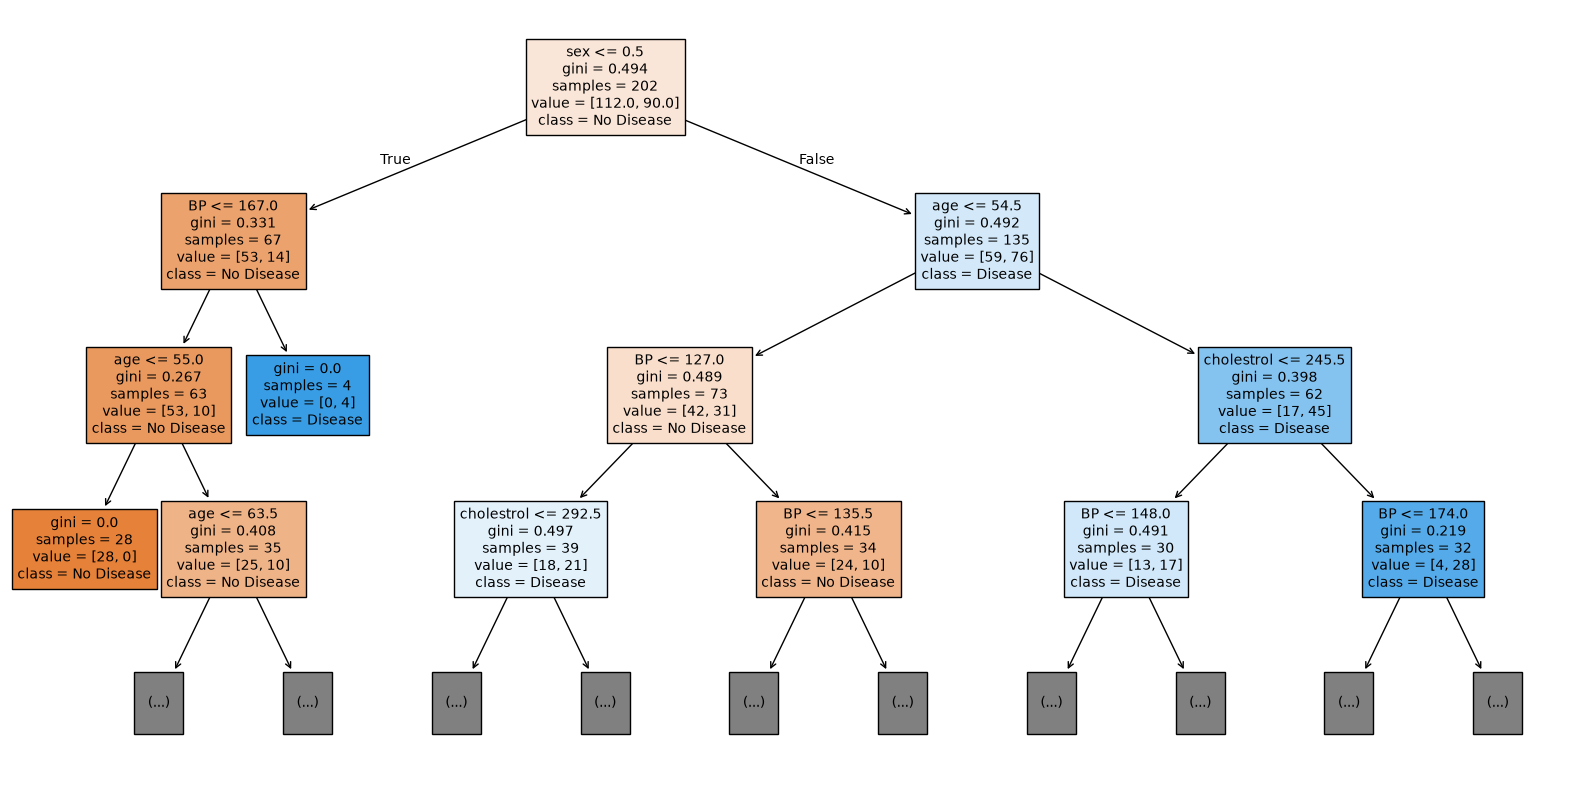

[saved plot] plots/assignment_3/decision_tree.png

First two splits:
  Node 0: if sex <= 0.50
  Node 1: if BP <= 167.00
  Node 22: if age <= 54.50


In [6]:
section("Part A: Train Decision Tree")

heart = pd.read_csv(DATA / "heart_disease.csv")
feature_cols = ["age", "sex", "BP", "cholestrol"]
target = "heart_disease"

print(f"Dataset size: {len(heart)} patients × {heart.shape[1]} columns")
print(f"Features: {feature_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    heart[feature_cols], heart[target], test_size=0.25, random_state=42, stratify=heart[target]
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))

print()
print(f"{'Metric':<22} {'Value':>10}")
print("-" * 34)
print(f"{'Train accuracy':<22} {pct(train_acc):>10}")
print(f"{'Test accuracy':<22} {pct(test_acc):>10}")
print(f"{'Train–test gap':<22} {pct(train_acc - test_acc):>10}  (large gap → overfitting)")

plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=feature_cols, class_names=["No Disease", "Disease"], filled=True, max_depth=3, fontsize=10)
show_plot("decision_tree.png", "assignment_3")

tree = dt.tree_
print("\nFirst two splits:")
for node in [0, tree.children_left[0], tree.children_right[0]]:
    if node >= 0 and tree.feature[node] >= 0:
        print(f"  Node {node}: if {feature_cols[tree.feature[node]]} <= {tree.threshold[node]:.2f}")



## Part B: Model Evaluation



  Part B: Evaluation metrics
Confusion matrix (rows=actual, cols=predicted):
                 Pred No Disease   Pred Disease
  Actual No            25                13
  Actual Disease       13                17

Classification report:
              precision    recall  f1-score   support

  No Disease     0.6579    0.6579    0.6579        38
     Disease     0.5667    0.5667    0.5667        30

    accuracy                         0.6176        68
   macro avg     0.6123    0.6123    0.6123        68
weighted avg     0.6176    0.6176    0.6176        68

Key rates:
  Precision (Disease): 56.67%
  Recall    (Disease): 56.67%
  Specificity:         65.79%
  Overall accuracy:    61.76%


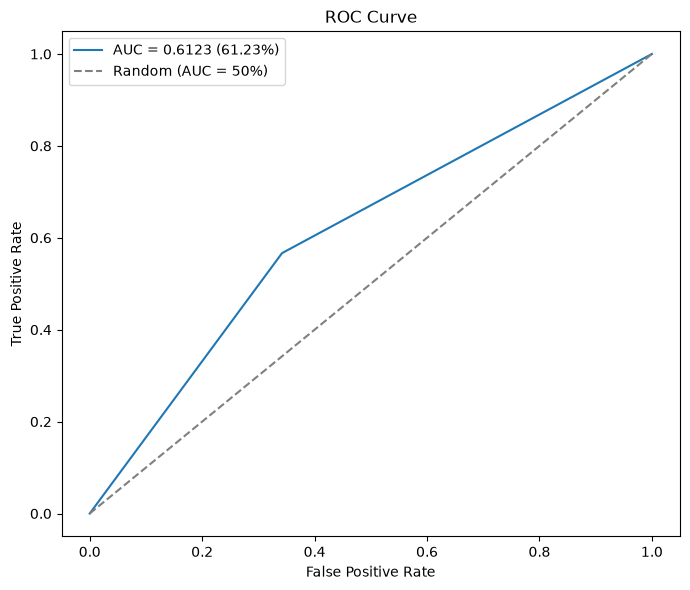

[saved plot] plots/assignment_3/roc_curve.png

AUC score: 0.6123  (61.23%)


In [7]:
section("Part B: Evaluation metrics")

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix (rows=actual, cols=predicted):")
print(f"                 Pred No Disease   Pred Disease")
print(f"  Actual No      {cm[0,0]:>8}          {cm[0,1]:>8}")
print(f"  Actual Disease {cm[1,0]:>8}          {cm[1,1]:>8}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"], digits=4))

# Convert report metrics to % summary
tn, fp, fn, tp = cm.ravel()
print("Key rates:")
print(f"  Precision (Disease): {pct(tp / (tp + fp) if (tp+fp) else 0)}")
print(f"  Recall    (Disease): {pct(tp / (tp + fn) if (tp+fn) else 0)}")
print(f"  Specificity:         {pct(tn / (tn + fp) if (tn+fp) else 0)}")
print(f"  Overall accuracy:    {pct(accuracy_score(y_test, y_pred))}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f} ({pct(auc)})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random (AUC = 50%)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
show_plot("roc_curve.png", "assignment_3")
print(f"\nAUC score: {auc:.4f}  ({pct(auc)})")



## Parts C–E: Tuning, Error Analysis, Class Imbalance



  Part C: Hyperparameter tuning
Train vs Test accuracy (%):

         param  train_%  test_%   gap_%
   max_depth=2  71.2900 64.7100  6.5800
   max_depth=4  77.2300 58.8200 18.4000
   max_depth=6  86.6300 72.0600 14.5700
max_depth=None 100.0000 61.7600 38.2400

Note: large train–test gap → overfitting; similar low scores → underfitting.

GridSearchCV best params: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV accuracy:  67.80%
Best test accuracy:66.18%

  Part D: Error analysis
Misclassified: 23 / 68  (33.82%)
Correct:       45 / 68  (66.18%)

Mean feature values:
            Correct  Misclassified
age         52.7800        57.7800
sex          0.6900         0.7400
BP         127.5300       135.7000
cholestrol 248.0700       266.3900

Pattern: misclassified patients often have moderate age/BP/cholesterol near decision boundaries.

  Part E: Class imbalance
Class           Count  Share
--------------------------------
No Disease        150  55.56%
Disease    

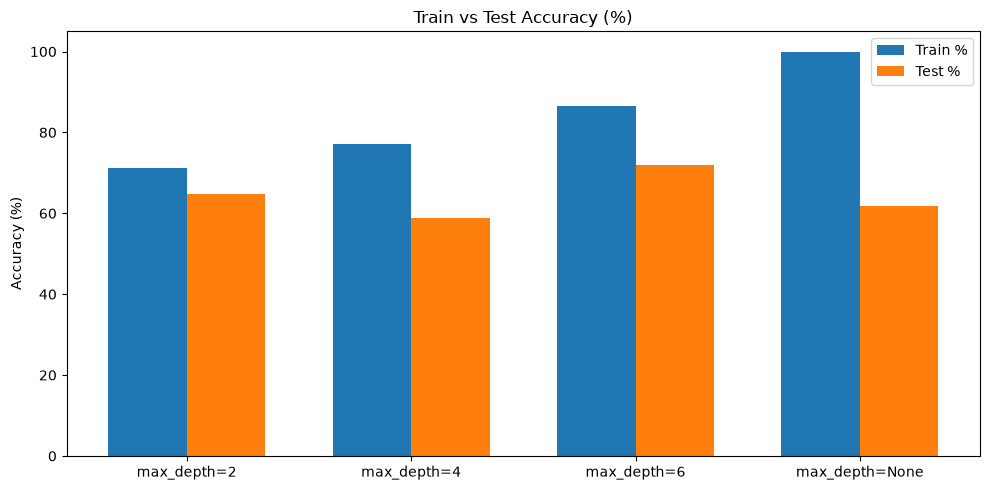

[saved plot] plots/assignment_3/train_vs_test_accuracy.png


In [8]:
section("Part C: Hyperparameter tuning")

tuning = []
for depth in [2, 4, 6, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    tuning.append({
        "param": f"max_depth={depth}",
        "train_%": round(100 * tr, 2),
        "test_%": round(100 * te, 2),
        "gap_%": round(100 * (tr - te), 2),
    })

tuning_df = pd.DataFrame(tuning)
print("Train vs Test accuracy (%):\n")
print(tuning_df.to_string(index=False))
print("\nNote: large train–test gap → overfitting; similar low scores → underfitting.")

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [2, 4, 6, 8, None], "min_samples_split": [2, 5, 10, 20], "min_samples_leaf": [1, 2, 5, 10]},
    cv=5,
).fit(X_train, y_train)
best = grid.best_estimator_
best_test = accuracy_score(y_test, best.predict(X_test))

print(f"\nGridSearchCV best params: {grid.best_params_}")
print(f"Best CV accuracy:  {pct(grid.best_score_)}")
print(f"Best test accuracy:{pct(best_test)}")

section("Part D: Error analysis")
test_df = X_test.copy()
test_df[target] = y_test.values
test_df["pred"] = best.predict(X_test)
correct = test_df[test_df[target] == test_df["pred"]]
mis = test_df[test_df[target] != test_df["pred"]]

print(f"Misclassified: {len(mis)} / {len(test_df)}  ({pct(len(mis)/len(test_df))})")
print(f"Correct:       {len(correct)} / {len(test_df)}  ({pct(len(correct)/len(test_df))})")

print("\nMean feature values:")
cmp = pd.DataFrame({
    "Correct": correct[feature_cols].mean(),
    "Misclassified": mis[feature_cols].mean(),
})
print(cmp.round(2).to_string())
print("\nPattern: misclassified patients often have moderate age/BP/cholesterol near decision boundaries.")

section("Part E: Class imbalance")
dist = heart[target].value_counts().sort_index()
print(f"{'Class':<14} {'Count':>6}  {'Share'}")
print("-" * 32)
for cls, n in dist.items():
    label = "No Disease" if cls == 0 else "Disease"
    print(f"{label:<14} {n:>6}  {pct(n/len(heart))}")

bal = balanced_accuracy_score(y_test, best.predict(X_test))
print(f"\nBalanced accuracy (best model): {pct(bal)}")

X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print("\nAfter SMOTE (train set balanced):")
print(pd.Series(y_res).value_counts().rename({0: "No Disease", 1: "Disease"}).to_string())

smote_model = DecisionTreeClassifier(**grid.best_params_, random_state=42).fit(X_res, y_res)
smote_acc = accuracy_score(y_test, smote_model.predict(X_test))
smote_bal = balanced_accuracy_score(y_test, smote_model.predict(X_test))
print(f"\nAfter SMOTE — test accuracy:     {pct(smote_acc)}")
print(f"After SMOTE — balanced accuracy: {pct(smote_bal)}")

x = np.arange(len(tuning_df)); w = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - w / 2, tuning_df["train_%"], w, label="Train %")
plt.bar(x + w / 2, tuning_df["test_%"], w, label="Test %")
plt.xticks(x, tuning_df["param"]); plt.ylabel("Accuracy (%)"); plt.legend()
plt.title("Train vs Test Accuracy (%)")
show_plot("train_vs_test_accuracy.png", "assignment_3")

